<a href="https://colab.research.google.com/github/kaplunov-dmitrii/diffury/blob/main/2253_%D0%9A%D0%B0%D0%BF%D0%BB%D1%83%D0%BD%D0%BE%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_%D0%BF%D1%80%D0%BE_%D0%BF%D0%BE%D0%BF%D1%83%D0%BB%D1%8F%D1%86%D0%B8%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as spec # библиотека для вычисления erf() — функции ошибок

In [88]:
a = 1.0
b = 0.1
c = 0.05

In [79]:
t = sp.symbols("t")
N = sp.Function("N")(t)
ode = sp.Eq(N.diff(t), -c*N*N - (b*t - a)*N)
ode

Eq(Derivative(N(t), t), -(0.1*t - 1.0)*N(t) - 0.05*N(t)**2)

In [89]:
N0 = 2.0
t0 = 0
t_end = 20
t_points = np.linspace(t0, t_end, 400)

In [81]:
solution = sp.dsolve(ode, N, ics={N.func(0): N0})
solution

Eq(N(t), exp(t*(1.0 - 0.05*t))/(16.5930956254427*sqrt(pi)*erf(0.223606797749979*t - 2.23606797749979) + 29.8644569825365))

In [90]:
#Ручное решение
C1 = 0.5 - 0.05 * np.exp(1.0**2 / 0.2) * np.sqrt(2/0.1) * (np.sqrt(np.pi)/2) * spec.erf(np.sqrt(0.1/2) * (0 - 1.0/0.1))
N_analytical = 1 / ((C1 + 0.05 * sp.exp(1.0**2 / (2*0.1)) * sp.sqrt(2/0.1) * (sp.sqrt(sp.pi)/2) * sp.erf(sp.sqrt(0.1/2) * (t - 1.0/0.1))) * sp.exp(0.1*t**2 / 2 - 1.0*t))
N_analytical_func = sp.lambdify(t, N_analytical, modules=['numpy', 'scipy'])
N_analytical_values = N_analytical_func(t_points)

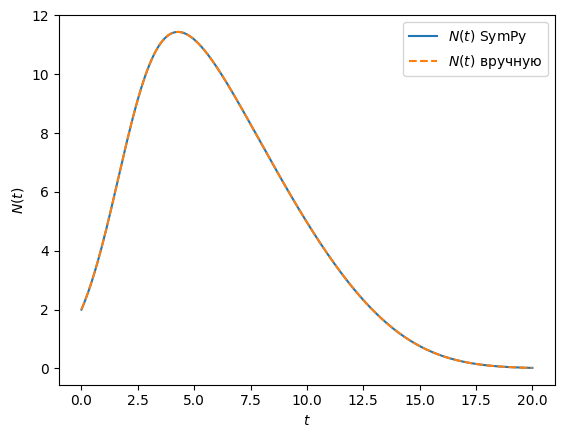

In [91]:
N_func = sp.lambdify(t, solution.rhs, modules=['numpy', 'scipy'])
N_values = N_func(t_points)

plt.plot(t_points, N_values, label=r'$N(t)$ SymPy')
plt.plot(t_points, N_analytical_values, label=r'$N(t)$ вручную', linestyle='--')

plt.xlabel(r'$t$')
plt.ylabel(r'$N(t)$')
plt.legend()
plt.show()

In [92]:
ode_b_0 = sp.Eq(N.diff(t), -c*N*N + a*N)
solution_b_0 = sp.dsolve(ode_b_0, N, ics={N.func(0): N0})

ode_c_0 = sp.Eq(N.diff(t), - (b*t - a)*N)
solution_c_0 = sp.dsolve(ode_c_0, N, ics={N.func(0): N0})

In [93]:
N_func_b_0 = sp.lambdify(t, solution_b_0.rhs, "numpy")
N_func_c_0 = sp.lambdify(t, solution_c_0.rhs, "numpy")

N_values_b_0 = N_func_b_0(t_points)
N_values_c_0 = N_func_c_0(t_points)

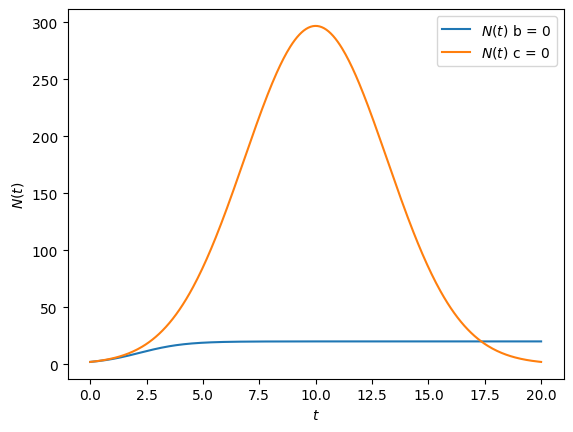

In [94]:
plt.plot(t_points, N_values_b_0, label=r'$N(t)$ b = 0 ()')
plt.plot(t_points, N_values_c_0, label=r'$N(t)$ c = 0')

plt.xlabel(r'$t$')
plt.ylabel(r'$N(t)$')
plt.legend()
plt.show()

При c = 0 время пика = 10

При b = 0 время пика уходит в бесконечность

В реальной модели время пика находится в районе 4-5. Это существенно меньше теоретического t* = a/b = 10